<a href="https://colab.research.google.com/github/HydraMi/Aplicadas/blob/main/Copia_de_Copia_de_Matem%C3%A1ticas_Aplicadas_II_Entrega2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://www.icesi.edu.co/wp-content/uploads/2024/10/ICESI_logo_prin_descriptor_RGB_NEGATIVO_0924-768x395.png width="300" height="200" align="center">

#**<big><big>Matemáticas Aplicadas II</big></big><br><small>Depto. Matemáticas & Estadística / Facultad de Ingeniería</small><br><small>_*Entrega 2*_ (Solución numérica de ecuaciones diferenciales ordinarias de primer orden). </small>**

A continuación se le pide contestar o resolver por grupo las siguientes preguntas, utilizando una copia del presente cuaderno para consignar todas sus respuestas con el formato requerido.

**Usted debe leer y trabajar en los problemas del cuaderno y traer preguntas para la sesión del miércoles 19 de febrero.** Dos **grupos** estarán encargados de socializar sus resultados

La entrega está para el día **viernes 21 de febrero**.

**<u>Preguntas</u>**

A continuación encuentra separadas por celda cada pregunta, así usted solo debe continuar escribiendo en la celda para dar cada respuesta. No olvide que todas sus respuestas deben ir acompañadas de al menos un argumento geométrico o numérico y uno algebráico o en lenguaje natural.


1. (30 ptos) *Método de Euler*

  La mayoría de métodos numéricos para encontrar soluciones aproximadas de una ecuación diferencial (problema de valor inicial)
  $$\frac{dx}{dt}=f(x,t),\quad x(0)=x_0$$

  reemplazan la derivada por un cociente de diferencias, esto es,
  
  $$\frac{x(t+h)-x(t)}{h}\approx f(x,t),\quad x(0)=x_0$$
  
  lo cual se reescribe como
  
  $$x(t+h)\approx x(t) + h f(x,t)$$
  
  o equivalentemente en términos de un ecuación de diferencias,

$$ x_{n+1}\approx x_n + h f(x_n,t_n).$$



Mounted at /content/drive


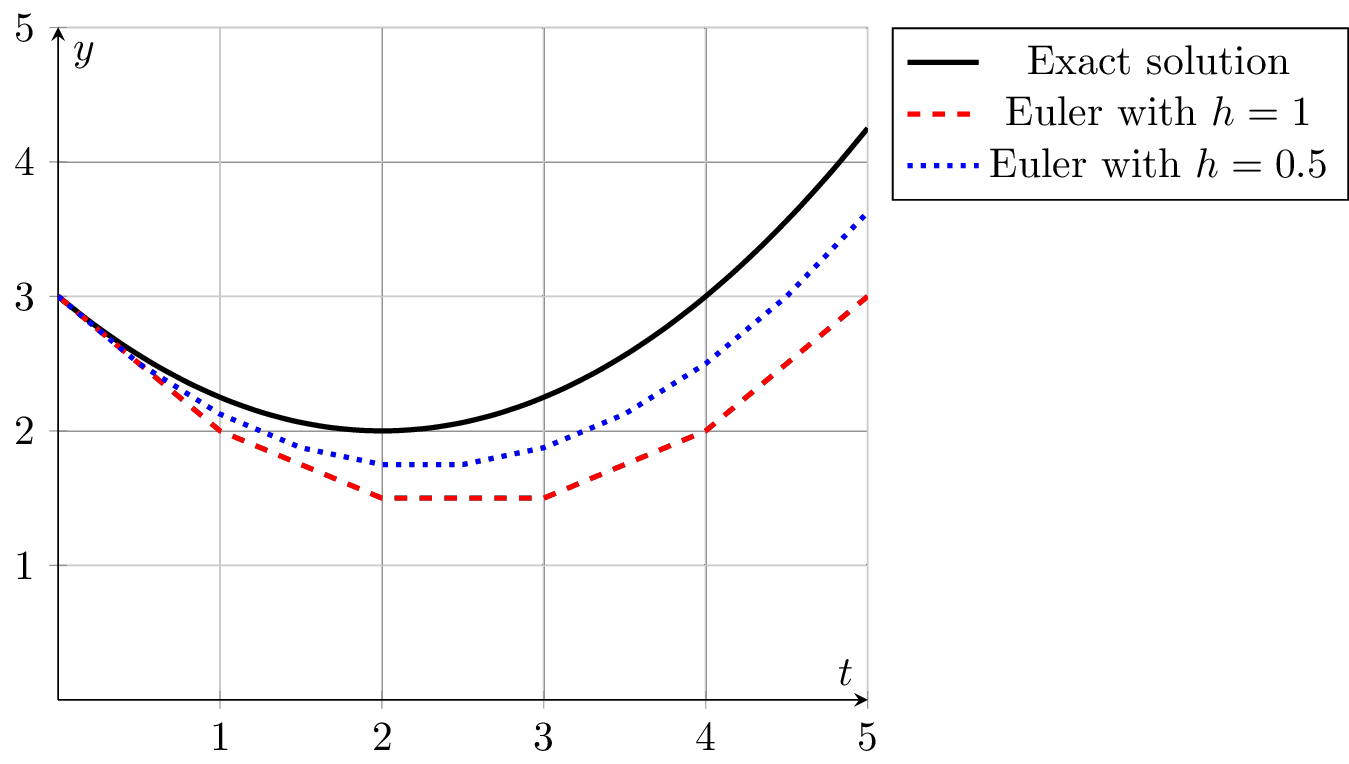

In [ ]:
from google.colab import files
from google.colab import drive

from IPython.display import Image

#drive.mount('/content/drive')

Image(filename='/content/drive/MyDrive/Figures/Euler.png')

Una forma de pensar en el método de Euler es que en un punto dado, la pendiente se aproxima por el valor del lado derecho de la ecuación diferencial y luego avanzamos $h$  unidades de tiempo siguiendo esa pendiente. La figura anterior muestra una representación de la idea. Observe en la figura que en regiones de alta curvatura, el método de Euler sobrepasará la solución exacta de la ecuación diferencial. Sin embargo, tomando el límite cuando $h$  tiende a $0$ teóricamente obtendremos la solución exacta (tomado de Numerical Methods An Inquiry-Based Approach With Python).

  
  1.1 Utilice su intuición y explique, ¿Por qué el método de Euler sobrepasaría la solución exacta en regiones donde la solución muestra una gran curvatura?

  1.2 Considere el siguiente problema de valor inicial: $$\frac{dx}{dt}=-\frac{1}{3}x+\sin(t),\quad x(0)=1,$$ cuya solución exacta viene dada por $$x(t)=\frac{1}{10}\left(19e^{-t/3}+3\sin(t)-9\cos(t)\right).$$ La idea es utilizar método de Euler  y comparar los errores relativos, tal como se definieron en la entrega anterior, en el intervalo $[0,5]$  para al menos valores de $n=5,10, 50$ y $100$.

  1.3  Modifique el código del método de Euler para graficar, como en la figura de la introducción, sus aproximaciones y la solución exacta, mostrando las respectivas etiquetas en cada caso y en la misma figura.

  1.4 En general, si tuviera que reducir el valor de la longitud de cada subintervalo  por la mitad, ¿qué haría eso con el valor del error? ¿Qué tal si dividimos por 10 o 100?

  1.5 Si queremos resolver numéricamente la ecuación diferencial de primer orden $\frac{dx}{dt}=f(x,t)$  en el intervalo $[0,1]$ con el método de Euler para obtener un error  máximo de $10^{-8}$  entre la solución numérica y la solución exacta, entonces, ¿ en cuántos puntos necesitamos  subdividir el intervalo $[0,1]$?

# Desarrollo 1.1

# ¿Por qué sobrepasa la solución exacta en regiones con gran curvatura?




# Como funciona Euler

Euler usa líneas rectas: La solución real puede ser una curva, pero Euler solo usa segmentos rectos para aproximarla.
La pendiente cambia rápido: Si la pendiente cambia mucho en un intervalo pequeño, Euler sigue avanzando con la pendiente antigua, lo que hace que se pase del valor real.
Se acumulan errores: Como cada paso introduce un pequeño error, si la solución tiene mucha curvatura, esos errores se van sumando y hacen que la aproximación de Euler sobrepase la solución exacta.




**$h$**: Es el **tamaño del paso** o **longitud del subintervalo**.
* Matemáticamente: $h = \frac{t_{\text{final}} - t_{\text{inicial}}}{n}$
* Es decir, $h$ es el tiempo que avanzas en cada paso al resolver la ecuación diferencial.


**$n$**: Es el **número de subintervalos** o **cantidad de pasos**.
* Es cuántas veces te vas a mover usando el método de Euler para avanzar desde el tiempo inicial hasta el tiempo final.
* Más $n$ significa que avanzas con más pasos pequeños, y el resultado es más preciso.

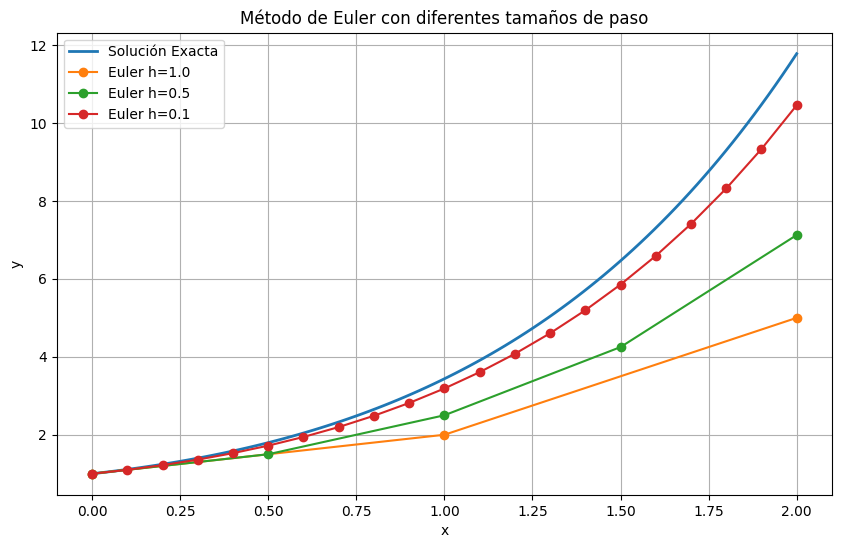

In [ ]:
#1.1
import numpy as np
import matplotlib.pyplot as plt

# Definimos la función derivada dy/dx = f(x, y)
def f(x, y):
    return x + y

# Solución exacta para la ecuación diferencial (en este caso particular)
def exact_solution(x):
    return -x - 1 + 2 * np.exp(x)

# Método de Euler
def euler(f, x0, y0, h, n):
    x_vals = [x0]
    y_vals = [y0]
    for i in range(n):
        y_next = y_vals[-1] + h * f(x_vals[-1], y_vals[-1])
        x_next = x_vals[-1] + h
        x_vals.append(x_next)
        y_vals.append(y_next)
    return np.array(x_vals), np.array(y_vals)

# Parámetros iniciales
x0 = 0
y0 = 1
x_end = 2

# Diferentes tamaños de paso
h_values = [1.0, 0.5, 0.1]

plt.figure(figsize=(10, 6))

# Gráfica de la solución exacta
x_exact = np.linspace(x0, x_end, 100)
y_exact = exact_solution(x_exact)
plt.plot(x_exact, y_exact, label='Solución Exacta', linewidth=2)

# Gráficas con diferentes pasos
for h in h_values:
    n_steps = int((x_end - x0) / h)
    x_euler, y_euler = euler(f, x0, y0, h, n_steps)
    plt.plot(x_euler, y_euler, marker='o', linestyle='-', label=f'Euler h={h}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Método de Euler con diferentes tamaños de paso')
plt.legend()
plt.grid(True)
plt.show()

Solución para evitar esto
Usar un paso más pequeño (
ℎ
h más chico) para que los segmentos rectos sigan mejor la curva.
o se puede usar el metodo de Runge-Kutta

# metodo de Runge-Kutta

El método de Runge-Kutta (RK4) es una mejora del método de Euler que ayuda a reducir el error sin necesidad de usar pasos demasiado pequeños. Se basa en calcular varias pendientes en cada paso y combinar la información para hacer una mejor aproximación.

¿Cómo funciona RK4?

En lugar de solo usar la pendiente en un punto (como hace Euler), RK4 calcula cuatro pendientes en cada paso:

1️⃣ $k_1$ → Se calcula la pendiente en el punto inicial.

2️⃣ $k_2$ → Se calcula la pendiente en el punto medio, avanzando la mitad del paso $h$.

3️⃣ $k_3$ → Se vuelve a calcular la pendiente en otro punto medio, usando la pendiente de $k_2$.

4️⃣ $k_4$ → Se calcula la pendiente en el siguiente punto, avanzando todo el paso $h$.
Luego, se hace un promedio ponderado de estas pendientes para obtener una mejor estimación:

La actualización de $x_n$ se realiza con la siguiente ecuación:

$x_{n+1} = x_n + \frac{h}{6} (k_1 + 2k_2 + 2k_3 + k_4)$




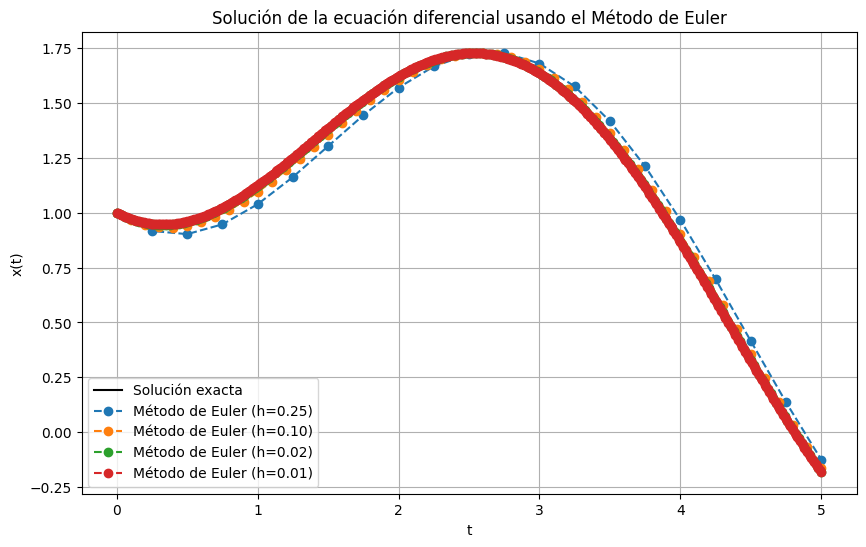

In [ ]:
# 1.2
import numpy as np
import matplotlib.pyplot as plt

# Definir la función f(x, t) de la ecuación diferencial dx/dt = -1/3 * x + sin(t)
def f(x, t):
    return - (1/3) * x + np.sin(t)

# Solución exacta de la ecuación diferencial
def exact_solution(t):
    return (1/10) * (19 * np.exp(-t/3) + 3 * np.sin(t) - 9 * np.cos(t))

# Método de Euler para resolver la ecuación diferencial
def euler_method(f, x0, t_range, n):
    t_values = np.linspace(t_range[0], t_range[1], n+1)
    h = (t_range[1] - t_range[0]) / n
    x_values = np.zeros(n+1)
    x_values[0] = x0

    for i in range(n):
        x_values[i+1] = x_values[i] + h * f(x_values[i], t_values[i])

    return t_values, x_values

# Valores iniciales
x0 = 1
t_range = [0, 5]
n_values = [20, 50, 250, 500]  # Correspondientes a h = 0.25, 0.1, 0.02, 0.01

plt.figure(figsize=(10, 6))

# Graficar la solución exacta
t_exact = np.linspace(t_range[0], t_range[1], 500)
x_exact = exact_solution(t_exact)
plt.plot(t_exact, x_exact, 'k-', label="Solución exacta")

# Resolver y graficar con el método de Euler para distintos valores de n
for n in n_values:
    t_euler, x_euler = euler_method(f, x0, t_range, n)
    h = (t_range[1] - t_range[0]) / n
    plt.plot(t_euler, x_euler, marker='o', linestyle='--', label=f"Método de Euler (h={h:.2f})")

# Configuración del gráfico
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Solución de la ecuación diferencial usando el Método de Euler')
plt.legend()
plt.grid(True)
plt.show()



**1.3  Modifique el código del método de Euler para graficar, como en la figura de la introducción, sus aproximaciones y la solución exacta, mostrando las respectivas etiquetas en cada caso y en la misma figura.**

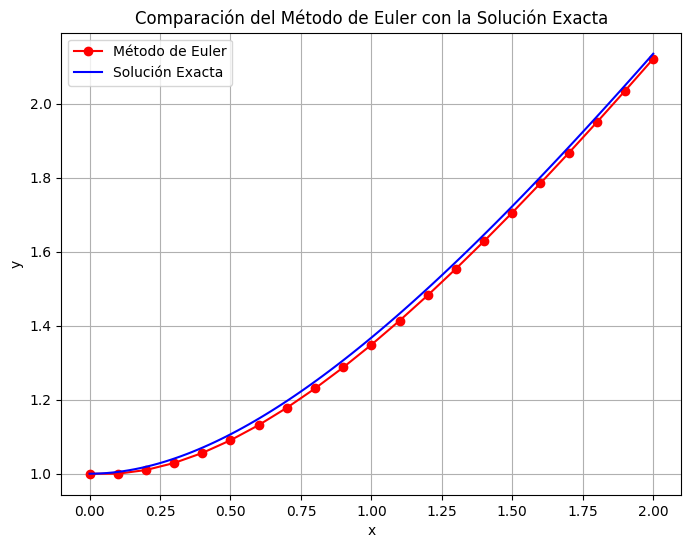

In [ ]:
#1.3
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -y + x + 1  # Ejemplo de ecuación diferencial

#Generamos una lista de valores de x con intervalos de tamaño h
#Se inicia una lista de valores de y con ceros y se asigna la condición incial
#Se aplica el método de Euler iterativamente, es decir que se repite varias veces

def euler_method(f, x0, y0, h, xn):
    x_values = np.arange(x0, xn + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = y0

    for i in range(1, len(x_values)):
        y_values[i] = y_values[i - 1] + h * f(x_values[i - 1], y_values[i - 1])

    return x_values, y_values

def exact_solution(x):
    return np.exp(-x) + x  # Solución exacta de la ecuación diferencial dada

# Parámetros iniciales
x0, y0 = 0, 1  # Condiciones iniciales de la ecuación diferencial
h = 0.1  # Tamaño de paso
xn = 2  # Valor final de x

# Cálculo de soluciones
x_euler, y_euler = euler_method(f, x0, y0, h, xn)  #calcula los valores aproximados usando el método de Euler
x_exact = np.linspace(x0, xn, 100)
y_exact = exact_solution(x_exact)  # Genera valores mas finos de x y se calcula la soluión exacta



#La gráfica permite visualizar la presición del método con la real
# Gráfica de soluciones
plt.figure(figsize=(8, 6))
plt.plot(x_euler, y_euler, 'ro-', label='Método de Euler')
plt.plot(x_exact, y_exact, 'b-', label='Solución Exacta')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparación del Método de Euler con la Solución Exacta')
plt.legend()
plt.grid()
plt.show()


# Desarrollo 1.4

Cuando reducimos el valor de la longitud de cada subintervalo (es decir, el paso
ℎ
h) por la mitad, por 10 o por 100, estamos haciendo los cálculos con pasos más pequeñitos.

Esto significa que:

- El método de Euler va a dar más puntos intermedios para seguir la curva.
- Como vamos más despacio, la línea recta que usamos en cada paso se parece más a la curva real.
- Entonces, el error se reduce porque nos desviamos menos de la solución exacta en cada pedazo.

hay una relacion entre el error y los metodos anteriormente mencionados.

**Método de Euler:**
* El error es proporcional a $h$.
* Si **reduces $h$ a la mitad**, el error también **se reduce más o menos a la mitad**.
* Si **divides $h$ por 10**, el error **se reduce aproximadamente 10 veces**.

**Método de Runge-Kutta de Orden 4 (RK4):**
* Es mucho más preciso. El error es proporcional a $h^4$.
* Si **reduces $h$ a la mitad**, el error **se reduce 16 veces** ($2^4 = 16$).
* Si **divides $h$ por 10**, el error **se reduce 10,000 veces** ($10^4 = 10,000$).


Por ejemplo:

Si con **$h = 0.1$** tienes un error de **0.05**, entonces:
* Si bajas a **$h = 0.05$**, el error será más o menos **0.025** (la mitad), con Euler.
* Pero si usas RK4, al bajar el paso por la mitad, el error cae muchísimo más.

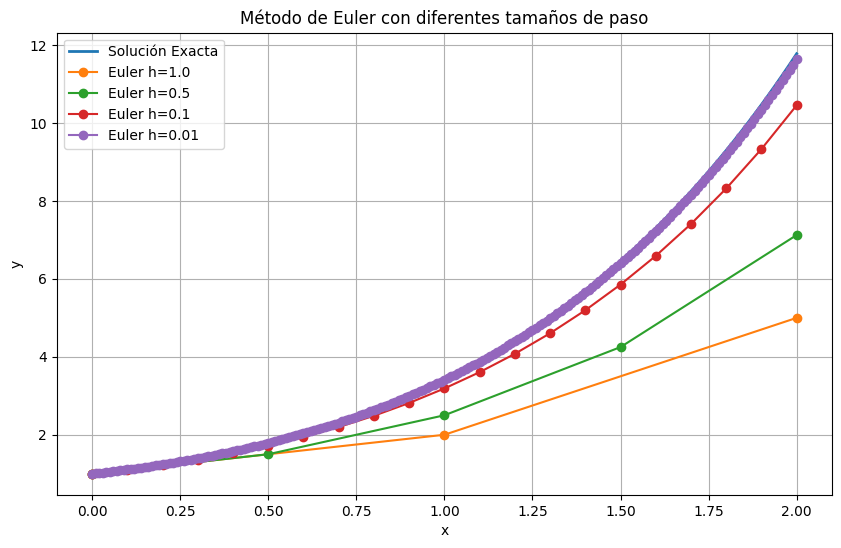

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos la función derivada dy/dx = f(x, y)
def f(x, y):
    return x + y

# Solución exacta para la ecuación diferencial (en este caso particular)
def exact_solution(x):
    return -x - 1 + 2 * np.exp(x)

# Método de Euler
def euler(f, x0, y0, h, n):
    x_vals = [x0]
    y_vals = [y0]
    for i in range(n):
        y_next = y_vals[-1] + h * f(x_vals[-1], y_vals[-1])
        x_next = x_vals[-1] + h
        x_vals.append(x_next)
        y_vals.append(y_next)
    return np.array(x_vals), np.array(y_vals)

# Parámetros iniciales
x0 = 0
y0 = 1
x_end = 2

# Diferentes tamaños de paso
h_values = [1.0, 0.5, 0.1, 0.01]  # Agregamos h = 0.01

plt.figure(figsize=(10, 6))

# Gráfica de la solución exacta
x_exact = np.linspace(x0, x_end, 100)
y_exact = exact_solution(x_exact)
plt.plot(x_exact, y_exact, label='Solución Exacta', linewidth=2)

# Gráficas con diferentes pasos
for h in h_values:
    n_steps = int((x_end - x0) / h)
    x_euler, y_euler = euler(f, x0, y0, h, n_steps)
    plt.plot(x_euler, y_euler, marker='o', linestyle='-', label=f'Euler h={h}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Método de Euler con diferentes tamaños de paso')
plt.legend()
plt.grid(True)
plt.show()



###1.5 Para resolver la ecuación diferencial de primer orden:

$\frac{dx}{dt} = f(x,t)$


en el intervalo $ [0,1] $ utilizando el método de Euler, con un error máximo permitido de $ 10^{-8} $, seguimos los siguientes pasos:

1. **Error Global del Método de Euler**  
   
   El error global del método de Euler es del orden de $ O(h) $, es decir,

   $E \approx O(h)$

   Para garantizar que el error no supere $ 10^{-8} $, debemos elegir $ h $ tal que:

   $h \leq 10^{-8}$

2. **Número de Subdivisiones**  
   
   Como el intervalo de integración es $ [0,1] $, el número de puntos $ N $ en la discretización se obtiene como:

   $N = \frac{1}{h}$

   Sustituyendo $ h = 10^{-8} $:
   
   $N = \frac{1}{10^{-8}} = 10^8$

Por lo tanto, se necesitan $ 10^8 $ puntos para garantizar un error máximo de $ 10^{-8} $.



2. (20 ptos) **Método del punto medio**. Hay diversas mejoras  al método clásico de Euler: algunas funcionan en casos especiales, algunas resuelven casos donde el error va a ser alto y otras son excelentes para soluciones numéricas de propósito general de EDO con una precisión relativamente alta.

El método del punto medio se define tomando la mitad del paso del método de Euler para aproximar la solución en el instante $t_{n+\frac{1}{2}}=\frac{t_n+t_{n+1}}{2}$. Luego tomamos un paso completo utilizando el valor de $f$ en $t_{n+\frac{1}{2}}$ y de esta manera aproximar $x_{n+\frac{1}{2}}$, esto es:

$$x_{n+\frac{1}{2}} = x_n + \frac{h}{2}f(x_n,t_n)$$
$$x_{n+1} = x_n + hf(x_{n+\frac{1}{2}},t_{n+\frac{1}{2}})$$

Dado que indexar utilizando $\frac{1}{2}$ no tiene sentido, la implementación se haría como sigue:

$$x_{temp}=x_n+\frac{h}{2}f(x_n,t_n)$$

$$x_{n+1}=x_n+hf(x_{temp},t_n+\frac{h}{2})$$
  
  2.1 Resuelva la ecuación diferencial del punto 1.2 con el método del punto medio en el intervalo $[0,4]$ y compare sus respuestas en terminos del error relativo para al menos dos particiones distintas del intervalo $[0,4]$.



**SOLUCIÓN**

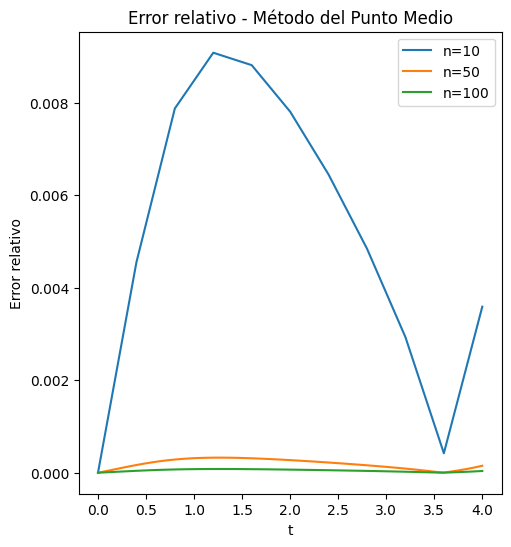

In [ ]:
#Defino la ecuación diferencial y la solución exacta
import numpy as np
import matplotlib.pyplot as plt

# Definimos la ecuación diferencial dx/dt = - (1/3) x + sin(t)
def f(t, x):
    return - (1/3) * x + np.sin(t)

# Solución exacta
def exact_solution(t):
    return (1/10) * (19 * np.exp(-t/3) + 3 * np.sin(t) - 9 * np.cos(t))

# Método del punto medio
def midpoint_method(f, x0, t_range, n):
    t_values = np.linspace(t_range[0], t_range[1], n+1)
    x_values = np.zeros(n+1)
    x_values[0] = x0
    h = (t_range[1] - t_range[0]) / n

    for i in range(n):
        x_half = x_values[i] + (h/2) * f(t_values[i], x_values[i])
        t_half = t_values[i] + h/2
        x_values[i+1] = x_values[i] + h * f(t_half, x_half)

    return t_values, x_values


# Cálculo del error relativo
def relative_error(approx, exact):
    return np.abs(approx - exact) / np.abs(exact)

# Valores de n para el método del punto medio
n_values_midpoint = [10, 50,100]
t_range_midpoint = [0, 4]

# Comparación del error relativo con el método del punto medio
errors_midpoint = {}
for n in n_values_midpoint:
    t_mid, x_mid = midpoint_method(f, 1, t_range_midpoint, n)
    x_exact_mid = exact_solution(t_mid)
    errors_midpoint[n] = relative_error(x_mid, x_exact_mid)

# Graficamos los errores relativos
plt.figure(figsize=(12, 6))


# Errores del Método del Punto Medio
plt.subplot(1, 2, 2)
for n in n_values_midpoint:
    t_mid, _ = midpoint_method(f, 1, t_range_midpoint, n)  # Recalcular t para cada n
    plt.plot(t_mid, errors_midpoint[n], label=f"n={n}")
plt.xlabel("t")
plt.ylabel("Error relativo")
plt.title("Error relativo - Método del Punto Medio")
plt.legend()

plt.show()

Podemos observar que el error también disminuye al aumentar el valor de n. Y el método del punto medio tiene menos errores en comparación con el  método de Euler

 2.2 Dibuje al menos cuatro de las aproximaciones junto con la solución exacta en dos gráficas distintas. ¿Qué conjeturas acerca de las aproximaciones puede hacer? Tome valores de $h=0.2,0.3,0.001,0.0001$ para apoyar sus observaciones.
  

   2.3 ¿Cuándo debería usar el método de Euler en lugar del método del punto medio? ¿Cuándo sería preferible usar el método del punto medio en lugar del método de Euler?
   

#Solución Punto 2.2

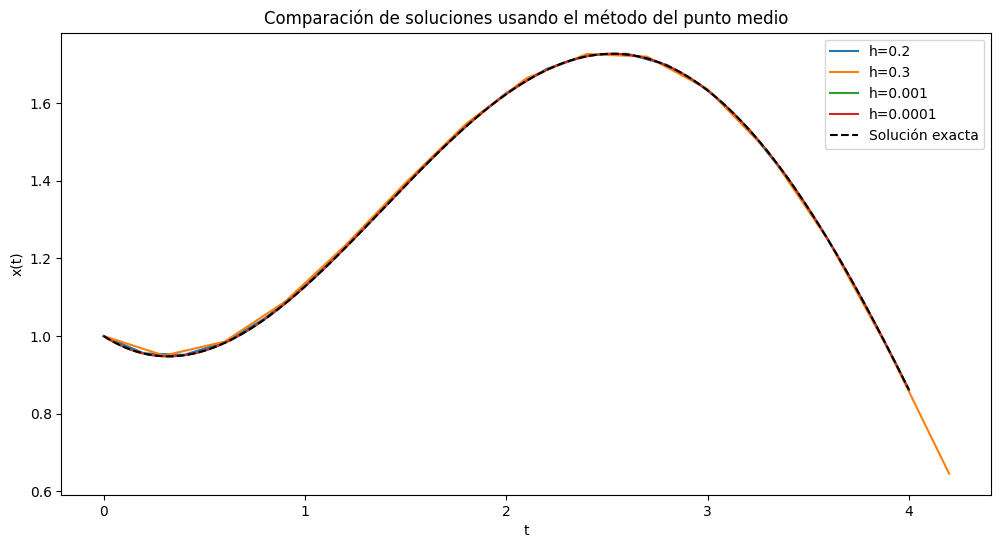

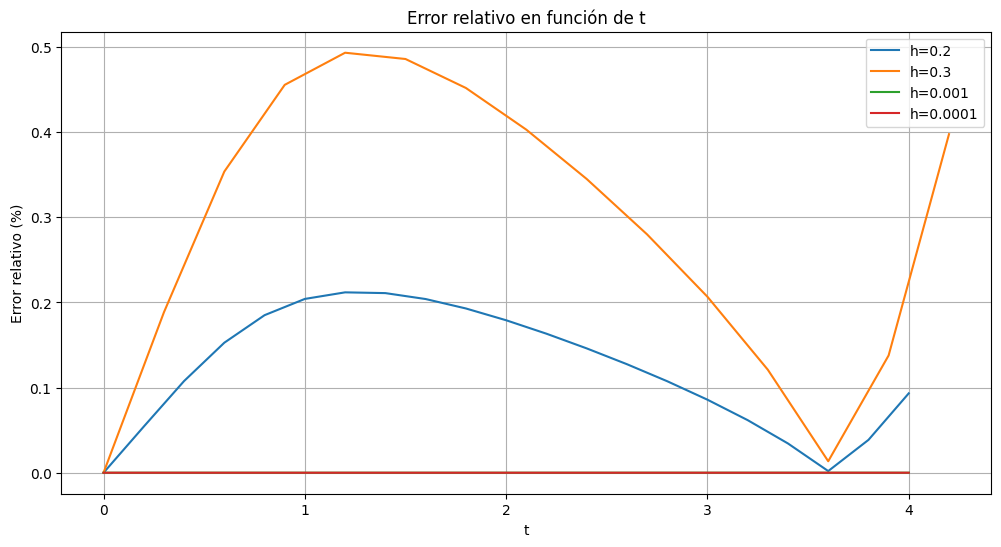

En la primera gráfica (comparación con la solución exacta):
Para valores grandes de h como 0.3 y 0.2, la aproximación se aleja bastante de la solución exacta.
Para valores pequeños de h como 0.001 y 0.0001, la aproximación sigue de cerca la solución exacta.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    return -x / 3 + np.sin(t)

def exact_solution(t):
    return (1/10) * (19 * np.exp(-t/3) + 3 * np.sin(t) - 9 * np.cos(t))

def midpoint_method(f, x0, t0, t_end, h):
    t_values = np.arange(t0, t_end + h, h)
    x_values = np.zeros(len(t_values))
    x_values[0] = x0

    for i in range(len(t_values) - 1):
        t_n = t_values[i]
        x_n = x_values[i]
        x_temp = x_n + (h / 2) * f(t_n, x_n)
        x_values[i + 1] = x_n + h * f(t_n + h / 2, x_temp)

    return t_values, x_values

def compute_relative_error(approx, exact):
    return np.abs((approx - exact) / exact) * 100  # Convertimos a porcentaje

# Parámetros
x0 = 1
t0 = 0
t_end = 4
hs = [0.2, 0.3, 0.001, 0.0001]

plt.figure(figsize=(12, 6))
for h in hs:
    t_values, x_values = midpoint_method(f, x0, t0, t_end, h)
    exact_values = exact_solution(t_values)
    plt.plot(t_values, x_values, label=f"h={h}")

# Solución exacta
t_exact = np.linspace(t0, t_end, 1000)
x_exact = exact_solution(t_exact)
plt.plot(t_exact, x_exact, 'k--', label='Solución exacta')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()
plt.title('Comparación de soluciones usando el método del punto medio')
plt.show()

# Gráfico de errores
plt.figure(figsize=(12, 6))
for h in hs:
    t_values, x_values = midpoint_method(f, x0, t0, t_end, h)
    exact_values = exact_solution(t_values)
    error = compute_relative_error(x_values, exact_values)
    plt.plot(t_values, error, label=f"h={h}")

plt.xlabel('t')
plt.ylabel('Error relativo (%)')
plt.legend()
plt.title('Error relativo en función de t')
plt.grid()
plt.show()

# Impresión de observaciones
print("En la primera gráfica (comparación con la solución exacta):")
print("Para valores grandes de h como 0.3 y 0.2, la aproximación se aleja bastante de la solución exacta.")
print("Para valores pequeños de h como 0.001 y 0.0001, la aproximación sigue de cerca la solución exacta.")

#Solución Punto 2.3

**Método de Euler**: Se puede usar cuando se requiere una implementación rápida y sencilla con precisión moderada, o cuando se tiene un problema donde una solución aproximada gruesa es suficiente.

**Método del punto medio:** Es preferible cuando se necesita una mayor precisión sin incrementar excesivamente el costo computacional. Dado que es un método de segundo orden, tiene menor error que Euler con un costo ligeramente mayor.

**La entrega solo se acepta en el formato de un cuaderno python colab .**